# Entraîner un modèle de régression avec Weli

Ce notebook montre un cycle complet : préparer `x` et `y`, séparer les données, construire et entraîner un modèle, suivre la perte, évaluer les résultats, faire des prédictions et sauvegarder/recharger le modèle.

Aucun fichier de données n'est nécessaire : les données d'exemple sont générées dans le notebook. Pour vos propres données, remplacez simplement `x` et `y` dans la cellule suivante par vos tableaux NumPy. `x` doit avoir la forme `(nombre_exemples, nombre_caractéristiques)` et `y` la forme `(nombre_exemples, nombre_sorties)`.

## 1. Importer les outils et préparer `x` et `y`

Ici, chaque exemple possède deux caractéristiques et la cible suit la relation `y = 2*x₀ - 0.5*x₁ + 1`, avec un peu de bruit aléatoire. C'est une tâche de régression : le modèle prédit une valeur numérique.

In [2]:
%pip install weli-ml

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import pandas as pd

In [6]:
data = pd.read_excel("../Data/Default.xlsx")

c:\Users\WIN11\Desktop\Weli\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [7]:
data.head(2)

,Unnamed: 0,default,student,balance,income
0,1,No,No,729.526495,44361.625074
1,2,No,Yes,817.180407,12106.134700


In [8]:
data.isna().sum()

Unnamed: 0    0
default       0
student       0
balance       0
income        0
dtype: int64

In [9]:
features = data[["default", "balance", "income"]].copy()
features["default"] = features["default"].map({"Yes": 1.0, "No": 0.0})

In [10]:
X = features.to_numpy(dtype=np.float64)
Y = (
    data["student"]
    .map({"Yes": 1.0, "No": 0.0})
    .to_numpy(dtype=np.float64)
    .reshape(-1, 1)
)

if not np.isfinite(X).all() or not np.isfinite(Y).all():
    raise ValueError("Les données contiennent des valeurs manquantes ou non convertibles.")

print("Valeurs invalides dans X :", (~np.isfinite(X)).sum())
print("Valeurs invalides dans Y :", (~np.isfinite(Y)).sum())
print("Valeurs distinctes de Y :", np.unique(Y))


Valeurs invalides dans X : 0
Valeurs invalides dans Y : 0
Valeurs distinctes de Y : [0. 1.]


In [11]:
# Mélanger les entrées et leurs cibles avec les mêmes indices.
np.random.seed(42)
indices = np.random.permutation(len(X))
X, Y = X[indices], Y[indices]

n_train = int(0.70 * len(X))
n_validation = int(0.15 * len(X))

x_train, y_train = X[:n_train], Y[:n_train]
x_validation = X[n_train:n_train + n_validation]
y_validation = Y[n_train:n_train + n_validation]
x_test, y_test = X[n_train + n_validation:], Y[n_train + n_validation:]

In [25]:
# Normaliser balance et income avec les statistiques du jeu d'entraînement.
mean = x_train[:, 1:].mean(axis=0)
std = x_train[:, 1:].std(axis=0)
std[std == 0] = 1.0
print(mean)
for subset in (x_train, x_validation, x_test):
    subset[:, 1:] = (subset[:, 1:] - mean) / std

[-4.02776225e-15  8.00632576e-15]


In [26]:


from weli.layers import Dense, ReLU
from weli.losses import MSE, BinaryCrossEntropy
from weli.models import Sequential, load_model
from weli.optimizers import Adam

np.random.seed(42)

# x is a pandas DataFrame here, so use .iloc for the first row
# instead of x[0], which would try to access a column named 0.

## 2. Séparer les données

On réserve une partie des exemples pour la validation et le test. La validation sert à suivre l'entraînement ; le jeu de test, gardé à part, sert à mesurer le résultat final.

In [14]:
# n_train = int(0.70 * len(x))
# n_validation = int(0.15 * len(x))

# x_train, y_train = x[:n_train], Y[:n_train]
# x_validation, y_validation = (
#     x[n_train:n_train + n_validation],
#     Y[n_train:n_train + n_validation],
# )
# x_test, y_test = x[n_train + n_validation:], Y[n_train + n_validation:]

# print("Entraînement :", x_train.shape, y_train.shape)
# print("Validation  :", x_validation.shape, y_validation.shape)
# print("Test        :", x_test.shape, y_test.shape)

## 3. Construire et configurer le modèle

Le réseau a deux couches denses : une couche cachée de 16 neurones avec activation ReLU, puis une sortie d'un neurone pour prédire `y`. `input_shape=(2,)` correspond aux deux caractéristiques d'un exemple, sans la dimension du lot.

In [38]:
model = Sequential([
    Dense(32),
    ReLU(),
     Dense(32),
     ReLU(),
    Dense(1),
], name="StudentClassifier")

model.compile(
    input_shape=(x_train.shape[1],),
    loss_fn=BinaryCrossEntropy(),
    optimizer=Adam(lr=0.001),
)




## 4. Entraîner le modèle

`history` contient les pertes d'entraînement et de validation à chaque époque. La perte MSE (erreur quadratique moyenne) doit généralement diminuer pendant l'entraînement.

In [28]:
model.summary()



Model: StudentClassifier
Layer (type)         Output Shape         Param #   
Dense (Dense)        (None, 32)           128       
ReLU (ReLU)          None                 0         
Dense (Dense)        (None, 32)           1056      
ReLU (ReLU)          None                 0         
Dense (Dense)        (None, 1)            33        
Total params: 1217
Trainable params: 1217
Non-trainable params: 0
Input shape: (3,)
Output shape: (1,)


In [ ]:
x_train = np.asarray(x_train, dtype=np.float64)
x_test = np.asarray(x_test, dtype=np.float64)
y_train = np.asarray(y_train, dtype=np.float64)
y_test = np.asarray(y_test, dtype=np.float64)
x_validation = np.asarray(x_validation, dtype=np.float64)
y_validation = np.asarray(y_validation, dtype=np.float64)

print(type(x_train), x_train.shape)
print(type(x_test), x_test.shape)
print(type(y_train), y_train.shape)
print(type(y_test), y_test.shape)
print(type(x_validation), x_validation.shape)
print(type(y_validation), y_validation.shape)

history = model.fit(
    x_train,
    y_train,
    epochs=250,
    batch_size=32,
    validation_data=(x_validation, y_validation),
    verbose=1,
    
    
)

<class 'numpy.ndarray'> (7000, 3)
<class 'numpy.ndarray'> (1500, 3)
<class 'numpy.ndarray'> (7000, 1)
<class 'numpy.ndarray'> (1500, 1)
<class 'numpy.ndarray'> (1500, 3)
<class 'numpy.ndarray'> (1500, 1)
Epoch 1/250 - loss: 0.3320 - acc: 0.8881 - val_loss: 0.2265 - val_acc: 0.8914
Epoch 2/250 - loss: 0.2614 - acc: 0.8570 - val_loss: 0.2999 - val_acc: 0.7988
Epoch 3/250 - loss: 0.3108 - acc: 0.7929 - val_loss: 0.3283 - val_acc: 0.7834
Epoch 4/250 - loss: 0.3000 - acc: 0.8038 - val_loss: 0.3151 - val_acc: 0.8341
Epoch 5/250 - loss: 0.3437 - acc: 0.7961 - val_loss: 0.3140 - val_acc: 0.8077
Epoch 6/250 - loss: 0.3104 - acc: 0.7966 - val_loss: 0.3139 - val_acc: 0.8077
Epoch 7/250 - loss: 0.3101 - acc: 0.7967 - val_loss: 0.3137 - val_acc: 0.8077
Epoch 8/250 - loss: 0.3097 - acc: 0.7969 - val_loss: 0.3135 - val_acc: 0.8077
Epoch 9/250 - loss: 0.3095 - acc: 0.7971 - val_loss: 0.3132 - val_acc: 0.8077
Epoch 10/250 - loss: 0.3091 - acc: 0.7976 - val_loss: 0.3129 - val_acc: 0.8077
Epoch 11/250 - 

<built-in method items of dict object at 0x000002637E615B80>


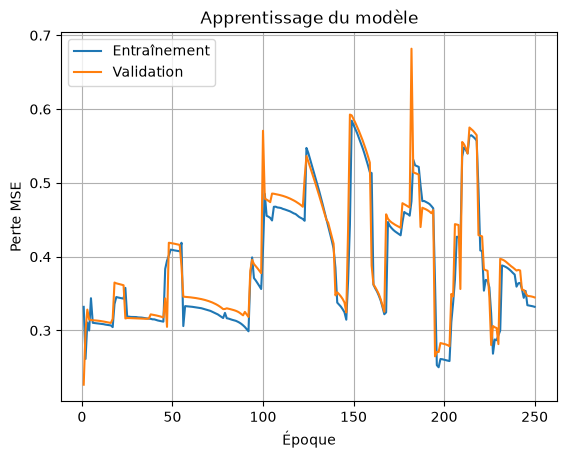

In [34]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)
plt.plot(epochs, history["train_loss"], label="Entraînement")
plt.plot(epochs, history["val_loss"], label="Validation")
plt.xlabel("Époque")
plt.ylabel("Perte MSE")
plt.title("Apprentissage du modèle")
plt.legend()
plt.grid(True)
plt.show()

## 5. Évaluer et faire des prédictions

L'évaluation est faite sur les exemples de test qui n'ont pas servi à entraîner le modèle. Weli renvoie aussi une accuracy, mais cette métrique simplifiée n'est pas significative pour la régression ; on ne retient donc que la perte. Les exemples affichent ensuite la cible réelle et la prédiction.

In [24]:
test_loss, _ = model.evaluate(x_test, y_test)
print(f"Perte MSE sur le jeu de test : {test_loss:.4f}")

x_exemples = x_test[:5]
y_reel = y_test[:5]
y_predit = model.predict(x_exemples)
print(y_reel - y_predit)
for entree, reel, predit in zip(x_exemples, y_reel, y_predit):
    print(f"x={entree} | y réel={reel[0]:.3f} | y prédit={predit[0]:.3f}")

Perte MSE sur le jeu de test : 0.3273
[[8.54288282e-02]
 [8.54288282e-02]
 [2.74056150e+05]
 [1.20120615e+05]
 [8.54288282e-02]]
x=[ 0.         -1.49307789 -1.4065823 ] | y réel=1.000 | y prédit=0.915
x=[ 0.         -0.0934028  -1.44137804] | y réel=1.000 | y prédit=0.915
x=[ 0.         -0.83311515  0.44980231] | y réel=0.000 | y prédit=-274056.150
x=[0.         0.79977573 0.2022586 ] | y réel=0.000 | y prédit=-120120.615
x=[ 0.         -0.08780225 -1.49649054] | y réel=1.000 | y prédit=0.915


## 6. Sauvegarder et recharger le modèle

Le fichier du modèle est enregistré dans le dossier de travail courant. Pour le réutiliser plus tard, chargez-le puis appelez `predict` sur de nouvelles entrées ayant les mêmes caractéristiques.

In [ ]:
chemin_modele = "../Data/weli_regression.weli"
model.save(chemin_modele)

modele_recharge = load_model(chemin_modele, compile=False)
predictions_rechargees = modele_recharge.predict(x_exemples)

np.testing.assert_allclose(y_predit, predictions_rechargees)
print(f"Modèle sauvegardé puis rechargé avec succès : {chemin_modele}")

Modèle sauvegardé puis rechargé avec succès : ../Data/weli_regression.weli
